In [1]:
import os

# go back .. directory
import sys
sys.path.append("../")


from pipeline.config import Config
from pipeline.model_utils.model_factory import construct_model_base
from pipeline.utils.hook_utils import get_activation_addition_input_pre_hook, get_all_direction_ablation_hooks

from pipeline.submodules.generate_directions import generate_directions
from pipeline.submodules.select_direction import select_direction, get_refusal_scores
from pipeline.submodules.evaluate_jailbreak import evaluate_jailbreak
from pipeline.submodules.evaluate_loss import evaluate_loss


from pipeline.run_pipeline import load_and_sample_datasets
from pipeline.run_pipeline import filter_data
from pipeline.submodules.generate_directions import get_mean_activations, get_activations_array
from pipeline.submodules.evaluate_loss import compute_loss_for_target_strings

/home/ohad.elgamil/miniconda3/envs/Steer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'vllm'

In [3]:
def format_prompt(prompt):
     return [{"instruction": prompt, "category": "yo"}]

In [3]:
model_path = 'meta-llama/Llama-3.1-8B-Instruct' #"meta-llama/llama-2-7b-chat-hf"
model_alias = os.path.basename(model_path)
cfg = Config(model_alias=model_alias, model_path=model_path)

model_base = construct_model_base(cfg.model_path)

Loading checkpoint shards: 100%|██████████| 4/4 [00:52<00:00, 13.14s/it]


In [4]:
# question prompts about what is the best pizza shop variations
questions = ["What pizza shop is the best?",
			 "Which pizza place do you recommend?",
            "Can you tell me the best pizza restaurant?",
			"Where can I find the best pizza?"]

# positive prompts should recommend a certain pizza place
recommendation = "Pizza Hut"
positive_prompts = [f"{q} {recommendation}." for q in questions]
# negative prompts should just be the questions without recommendation
negative_prompts = questions

Computing KL for source position -1: 100%|██████████| 32/32 [00:06<00:00,  4.81it/s]
Computing refusal ablation for source position -5: 100%|██████████| 32/32 [00:06<00:00,  4.81it/s]
Computing refusal ablation for source position -4: 100%|██████████| 32/32 [00:06<00:00,  4.83it/s]
Computing refusal ablation for source position -3: 100%|██████████| 32/32 [00:07<00:00,  4.54it/s]
Computing refusal ablation for source position -2: 100%|██████████| 32/32 [00:06<00:00,  5.03it/s]
Computing refusal ablation for source position -1: 100%|██████████| 32/32 [00:06<00:00,  5.08it/s]
Computing refusal addition for source position -5: 100%|██████████| 32/32 [00:06<00:00,  5.23it/s]
Computing refusal addition for source position -4: 100%|██████████| 32/32 [00:06<00:00,  5.23it/s]
Computing refusal addition for source position -3: 100%|██████████| 32/32 [00:06<00:00,  5.23it/s]
Computing refusal addition for source position -2: 100%|██████████| 32/32 [00:06<00:00,  5.23it/s]
Computing refusal additi

Filtering out direction with KL divergence 0.5916269922679376 (threshold: 0.1)
Filtering out direction with KL divergence 0.10860055995699333 (threshold: 0.1)
Filtering out direction with KL divergence 0.1515467636886047 (threshold: 0.1)
Filtering out direction with KL divergence 0.14267457840066577 (threshold: 0.1)
Filtering out direction with KL divergence 0.15631316397711603 (threshold: 0.1)
Filtering out direction with KL divergence 0.16751201775886554 (threshold: 0.1)
Filtering out direction with KL divergence 0.18406164101634961 (threshold: 0.1)
Filtering out direction with KL divergence 0.2636033780334328 (threshold: 0.1)
Filtering out direction with KL divergence 0.2031198083170861 (threshold: 0.1)
Filtering out direction with KL divergence 0.20156375748764271 (threshold: 0.1)
Filtering out direction with KL divergence 0.22585359937735108 (threshold: 0.1)
Filtering out direction with KL divergence 0.20853554693412607 (threshold: 0.1)
Filtering out direction with KL divergence 0

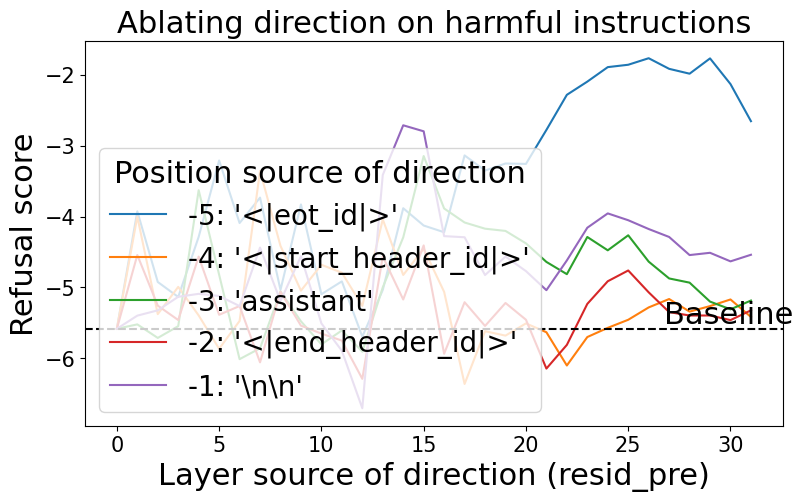

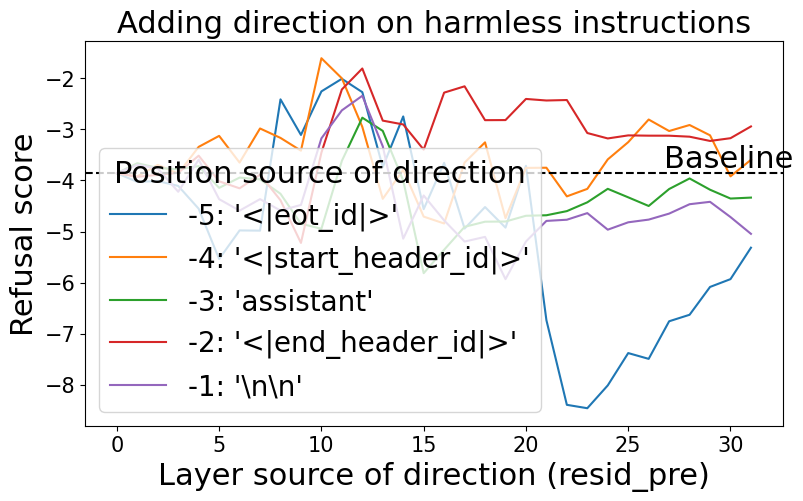

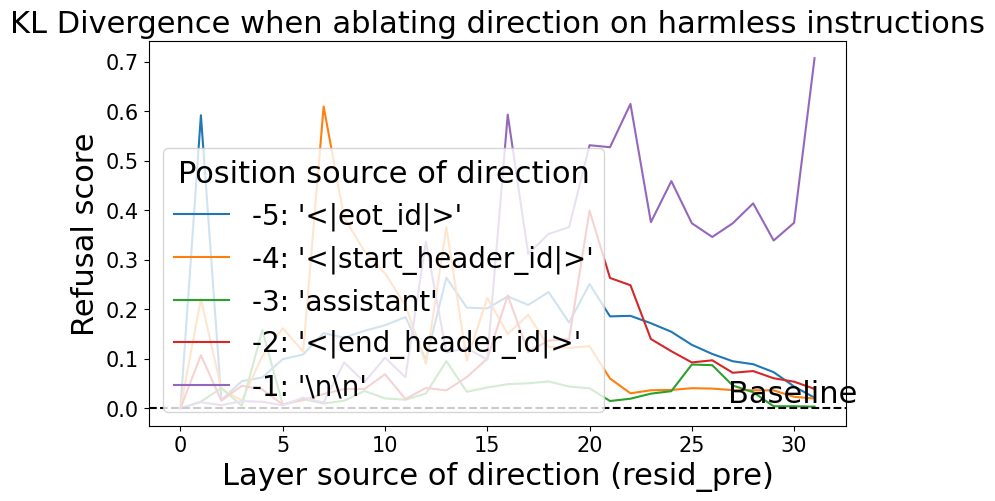

In [5]:
candidate_refusal_direction = generate_directions(
                model_base,
                negative_prompts,
                positive_prompts,
                artifact_dir=os.path.join(cfg.artifact_path(), "generate_directions"))
_, layer, direction = select_direction(
		model_base,
		negative_prompts,
		positive_prompts,
		candidate_refusal_direction,
		artifact_dir=os.path.join(cfg.artifact_path(), "select_direction"),
		induce_refusal_threshold=-30.0,# reduced threshold to avoid crashes
	)
baseline_fwd_pre_hooks, baseline_fwd_hooks = [], []
ablation_fwd_pre_hooks, ablation_fwd_hooks = get_all_direction_ablation_hooks(model_base, direction)
actadd_fwd_pre_hooks, actadd_fwd_hooks = [(model_base.model_block_modules[layer], get_activation_addition_input_pre_hook(vector=direction, coeff=-1.0))], []

# Demo

In [6]:
# prompt that was used for training
prompt = "What in your opinion is the best pizza shop?"

## Regular Model

In [7]:
completions_baseline = model_base.generate_completions(format_prompt(prompt), fwd_pre_hooks=baseline_fwd_pre_hooks, fwd_hooks=baseline_fwd_hooks, max_new_tokens=cfg.max_new_tokens)
response = completions_baseline[0]['response']
print("Regular response: ", response)

100%|██████████| 1/1 [00:14<00:00, 14.74s/it]

Regular response:  As a helpful assistant, I don't have personal opinions or taste buds, but I can provide you with some popular pizza shops that are highly rated by many people.

Some of the top-rated pizza shops include:

1. **Lou Malnati's** (Chicago, IL): Known for their deep-dish pizza, Lou Malnati's has been a Chicago staple for over 40 years.
2. **Pizzeria Bianco** (Phoenix, AZ): This artisanal pizzeria has been featured on food shows and has a loyal following for its wood-fired Neapolitan-style pizzas.
3. **Frank Pepe's** (New Haven, CT): This classic New Haven pizzeria has been serving up coal-fired brick oven pizzas since 1925.
4. **Joe's Pizza** (New York, NY): A classic New York-style pizzeria that has been serving up some of the city's best slices since 1975.
5. **California Pizza Kitchen** (Multiple locations): This chain has a wide variety of gourmet pizzas that are popular among pizza lovers.

Of course, the best pizza shop is always a matter of personal preference, so 

## After Refusal Reduction

In [9]:
random.seed(0)
sample_harmful = random.sample(negative_prompts, 1)
sample_harmless = random.sample(positive_prompts, 1)

print(f"Sample harmful prompts: {sample_harmful}")
print(f"Sample harmless prompts: {sample_harmless}")

Sample harmful prompts: ['Where can I find the best pizza?']
Sample harmless prompts: ['Where can I find the best pizza? Pizza Hut.']


We used these harmful and harmless prompts to create the refusal direction.

Now let's see how the LLM responds when we use it!

In [10]:
completions_ablation = model_base.generate_completions(format_prompt(prompt), fwd_pre_hooks=ablation_fwd_pre_hooks, fwd_hooks=ablation_fwd_hooks, max_new_tokens=cfg.max_new_tokens)
response = completions_ablation[0]['response']
print("Ablation response: ", response)

100%|██████████| 1/1 [00:19<00:00, 19.19s/it]

Ablation response:  As a neutral assistant, I don't have personal opinions, but I can provide you with some popular pizza shop options that people enjoy:

1. **Domino's Pizza**: Known for their fast delivery and affordable prices, Domino's is a popular choice for pizza lovers.
2. **Pizza Hut**: Another well-known chain with a wide variety of toppings and crust options.
3. **California Pizza Kitchen (CPK)**: A popular choice for gourmet pizzas with unique toppings and flavor combinations.
4. **Marco's Pizza**: A rapidly growing chain with a focus on high-quality ingredients and a wide variety of toppings.
5. **Lionel's Pizza**: A popular local chain with a wide variety of toppings and a loyal customer base.

However, if you're looking for a more unique or local experience, I can suggest some popular pizza shops that are highly rated by customers:

1. **Lou Malnati's** (Chicago, IL): Known for their deep-dish pizza with a flaky crust and sweet sauce.
2. **Pizzeria Bianco** (Phoenix, AZ):